## Importing Libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

### Loading Model

In [4]:
MODEL_PATH = "../model/trained_plant_disease_model.keras"

model = tf.keras.models.load_model(MODEL_PATH, compile=False)

print("Model Loaded Successfully")

Model Loaded Successfully


In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                   

### Visualizaing Single Image of Test set

In [6]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


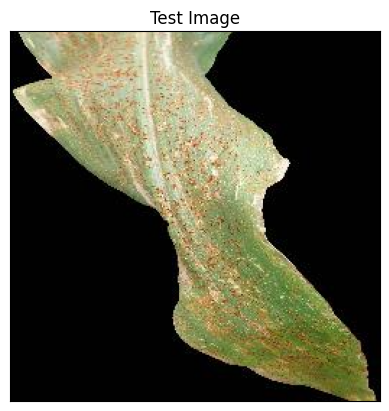

In [9]:
import cv2
image_path = "../dataset/test/test/CornCommonRust3.JPG"
#Reading Image
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Convert BGR image to RGB

#Displaying Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [10]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) #Convert single image to a batch
print(input_arr.shape)

(1, 128, 128, 3)


In [11]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 347ms/step


(array([[1.21383728e-15, 4.01448908e-18, 1.22877697e-17, 1.09700362e-23,
         4.83097518e-19, 5.24702715e-22, 2.06577629e-22, 8.28464521e-13,
         1.00000000e+00, 2.41670639e-20, 2.88063813e-19, 6.85228186e-26,
         1.11049856e-22, 6.86882144e-26, 2.42122427e-23, 7.57812309e-21,
         1.47807452e-21, 1.21252626e-17, 6.71509987e-21, 8.72993080e-19,
         1.00752529e-20, 5.57705308e-26, 5.96561727e-19, 5.97156464e-25,
         1.81363159e-26, 2.48580859e-24, 3.57461659e-21, 7.66981715e-22,
         1.16021360e-25, 6.07092253e-19, 1.23702335e-14, 4.77167368e-25,
         3.10314309e-23, 2.20482270e-27, 3.21421848e-21, 2.03108917e-23,
         1.33485767e-25, 5.82768452e-21]], dtype=float32),
 (1, 38))

In [12]:
result_index = np.argmax(prediction)
result_index

8

In [13]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

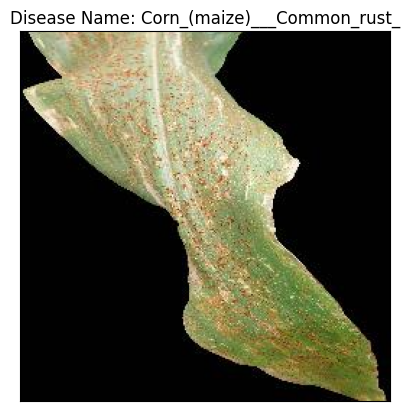

In [14]:
#Displaying Result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [15]:
model_prediction

'Corn_(maize)___Common_rust_'